In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from mne.preprocessing import ICA
from mne_icalabel import label_components
from scipy.signal import stft
from scipy.stats import zscore

In [2]:
CANE_DIR = Path("../CANE/")
MDD_DIR = Path("../MDD/")

In [3]:
raw = mne.io.read_raw_edf(MDD_DIR / "MDD S1 EC.edf", preload=True)
print(raw.info)
raw

Extracting EDF parameters from /home/milan/Documents/diplomka/MDD/MDD S1 EC.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 77567  =      0.000 ...   302.996 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: EEG Fp1-LE, EEG F3-LE, EEG C3-LE, EEG P3-LE, EEG O1-LE, EEG ...
 chs: 20 EEG
 custom_ref_applied: False
 highpass: 0.5 Hz
 lowpass: 80.0 Hz
 meas_date: 2013-06-06 16:44:47 UTC
 nchan: 20
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: Ab_Ibrahim_W0, sex: 1, last_name: XX, birthday: 2001-01-01>
>


<RawEDF | MDD S1 EC.edf, 20 x 77568 (303.0 s), ~11.9 MiB, data loaded>

In [4]:
print("\nAll available channels:")
print(raw.ch_names)


All available channels:
['EEG Fp1-LE', 'EEG F3-LE', 'EEG C3-LE', 'EEG P3-LE', 'EEG O1-LE', 'EEG F7-LE', 'EEG T3-LE', 'EEG T5-LE', 'EEG Fz-LE', 'EEG Fp2-LE', 'EEG F4-LE', 'EEG C4-LE', 'EEG P4-LE', 'EEG O2-LE', 'EEG F8-LE', 'EEG T4-LE', 'EEG T6-LE', 'EEG Cz-LE', 'EEG Pz-LE', 'EEG A2-A1']


Using matplotlib as 2D backend.


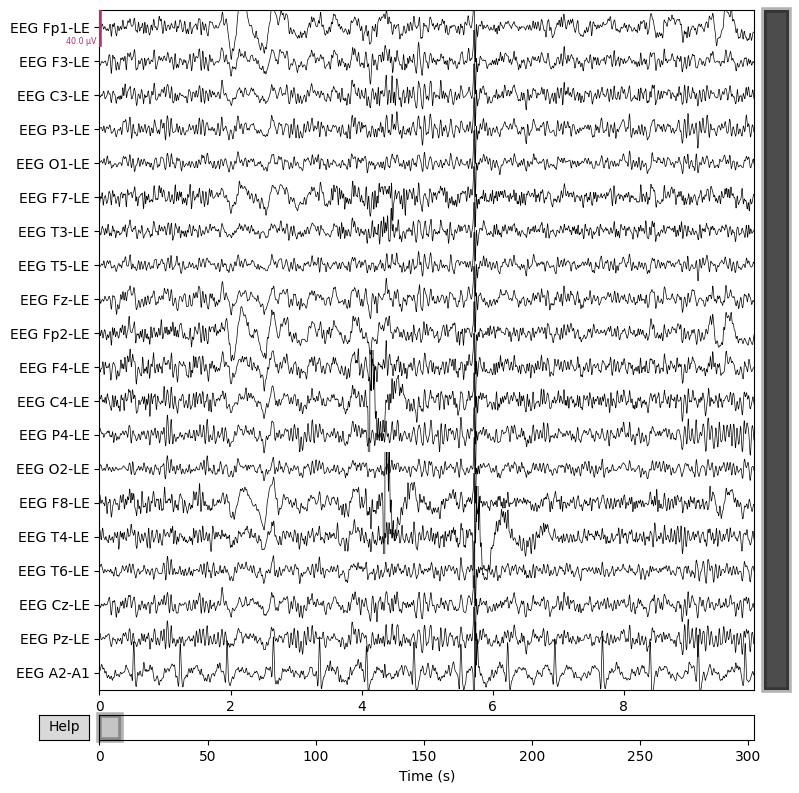

In [5]:
_ = raw.plot()

## Preprocessing MDD dataset

In [6]:
# https://en.wikipedia.org/wiki/Butterworth_filter
# ICA is sensitive to low-frequency drifts and therefore requires the data to be
# high-pass filtered prior to fitting. Typically, a cutoff frequency of 1 Hz is
# recommended.
# ^ from ICA docs: https://mne.tools/stable/generated/mne.preprocessing
# .ICA.html#mne.preprocessing.ICA
raw = raw.filter(l_freq=1, h_freq=70, method="iir")
raw = raw.notch_filter(freqs=50)

# TODO not sure about Cz; Add T7, T8 - ma to nejake ackove, chceckni ten clanek
raw = raw.pick(["EEG Fp1-LE", "EEG Fp2-LE", "EEG C3-LE", "EEG C4-LE", "EEG O2-LE", "EEG Cz-LE"])
mapping = {
    "EEG Fp1-LE": "Fp1",
    "EEG Fp2-LE": "Fp2",
    "EEG C3-LE": "C3",
    "EEG C4-LE": "C4",
    "EEG O2-LE": "O2",
    "EEG Cz-LE": "Cz",
}
raw = raw.rename_channels(mapping)

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 70 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 1.00, 70.00 Hz: -6.02, -6.02 dB

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 49 - 51 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 49.38
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 49.12 Hz)
- Upper passband edge: 50.62 Hz
- Upper transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 50.88 Hz)
- Filter length: 1691 samples (6.605 s)



In [7]:
raw.info

<Info | 8 non-empty values
 bads: []
 ch_names: Fp1, Fp2, C3, C4, O2, Cz
 chs: 6 EEG
 custom_ref_applied: False
 highpass: 1.0 Hz
 lowpass: 70.0 Hz
 meas_date: 2013-06-06 16:44:47 UTC
 nchan: 6
 projs: []
 sfreq: 256.0 Hz
 subject_info: <subject_info | his_id: Ab_Ibrahim_W0, sex: 1, last_name: XX, birthday: 2001-01-01>
>

In [8]:
# remember, we're applying the ICA solution from the filtered data to the original
# unfiltered signal. Why?? read it properly
# https://mne.tools/mne-icalabel/0.4/generated/examples/
# 00_iclabel_automatic_artifact_correction_ica.html

# TODO: maybe use autoreject library instead
filt_raw = raw.set_eeg_reference("average")
ica = ICA(
    max_iter="auto",
    method="infomax",
    random_state=97,  # seed?
    fit_params=dict(extended=True),
)
ica.fit(filt_raw)
ica

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Fitting ICA to data using 6 channels (please be patient, this may take a while)
Selecting by non-zero PCA components: 5 components
Computing Extended Infomax ICA
Fitting ICA took 7.0s.


Method,infomax
Fit parameters,extended=Truemax_iter=500
Fit,500 iterations on raw data (77568 samples)
ICA components,5
Available PCA components,6
Channel types,eeg
ICA components marked for exclusion,—


In [9]:
montage = mne.channels.make_standard_montage("standard_1020")
montage
# 2. Apply montage (MNE will keep only those channels that exist in raw)
filt_raw = filt_raw.set_montage(montage, match_case=False)
ic_labels = label_components(filt_raw, ica, method="iclabel")

/tmp/ipykernel_13338/2214068080.py:5: RuntimeWarning: The provided Raw instance is not filtered between 1 and 100 Hz. ICLabel was designed to classify features extracted from an EEG dataset bandpass filtered between 1 and 100 Hz (see the 'filter()' method for Raw and Epochs instances).
  ic_labels = label_components(filt_raw, ica, method="iclabel")


In [10]:
labels = ic_labels["labels"]
print(labels)
exclude_idx = [idx for idx, label in enumerate(labels) if label not in ["brain", "other"]]
print(f"Excluding these ICA components: {exclude_idx}")
# ica.apply() changes the Raw object in-place, so let's make a copy first:
preprocessed = filt_raw.copy()
ica.apply(preprocessed, exclude=exclude_idx)

['brain', 'brain', 'brain', 'brain', 'eye blink']
Excluding these ICA components: [4]
Applying ICA to Raw instance
    Transforming to ICA space (5 components)
    Zeroing out 1 ICA component
    Projecting back using 6 PCA components


<RawEDF | MDD S1 EC.edf, 6 x 77568 (303.0 s), ~3.6 MiB, data loaded>

Applying ICA to Raw instance
    Transforming to ICA space (5 components)
    Zeroing out 0 ICA components
    Projecting back using 6 PCA components


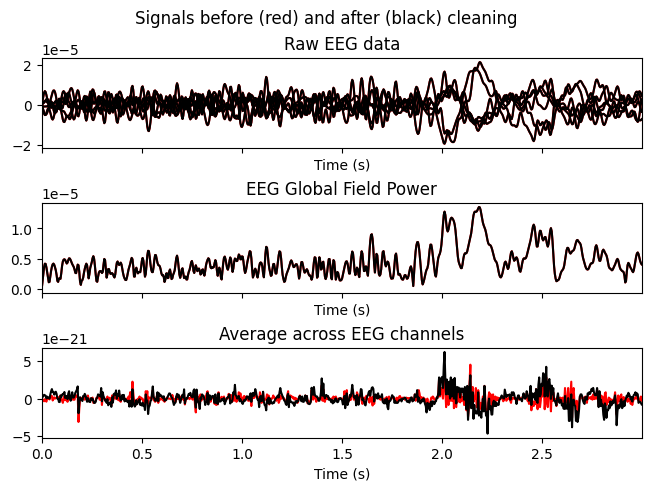

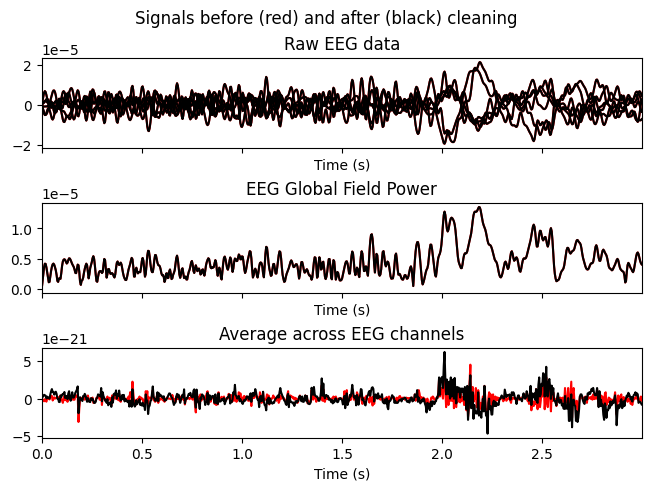

In [11]:
ica.plot_overlay(filt_raw)

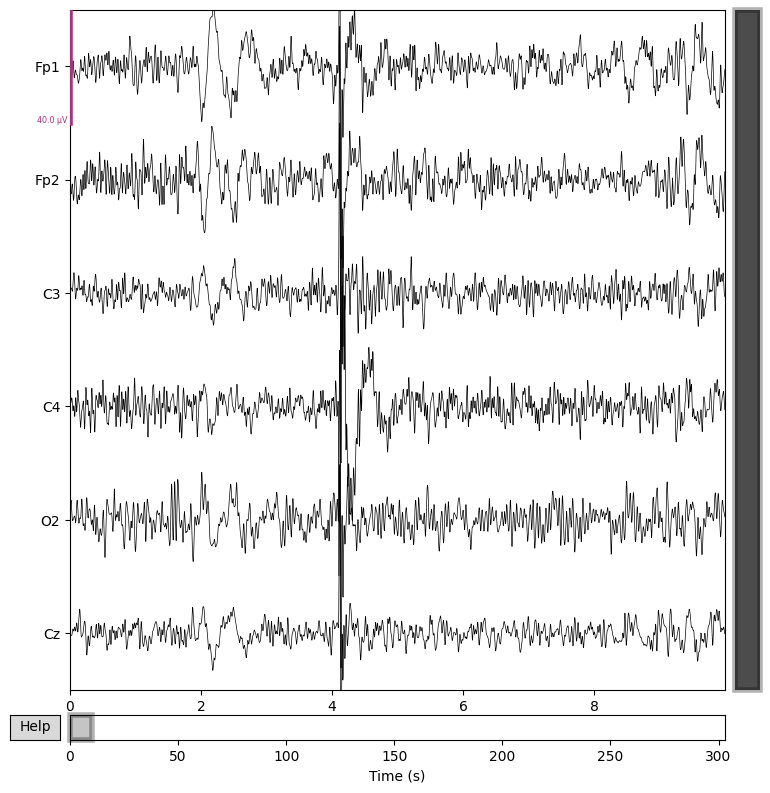

In [12]:
_ = filt_raw.plot()

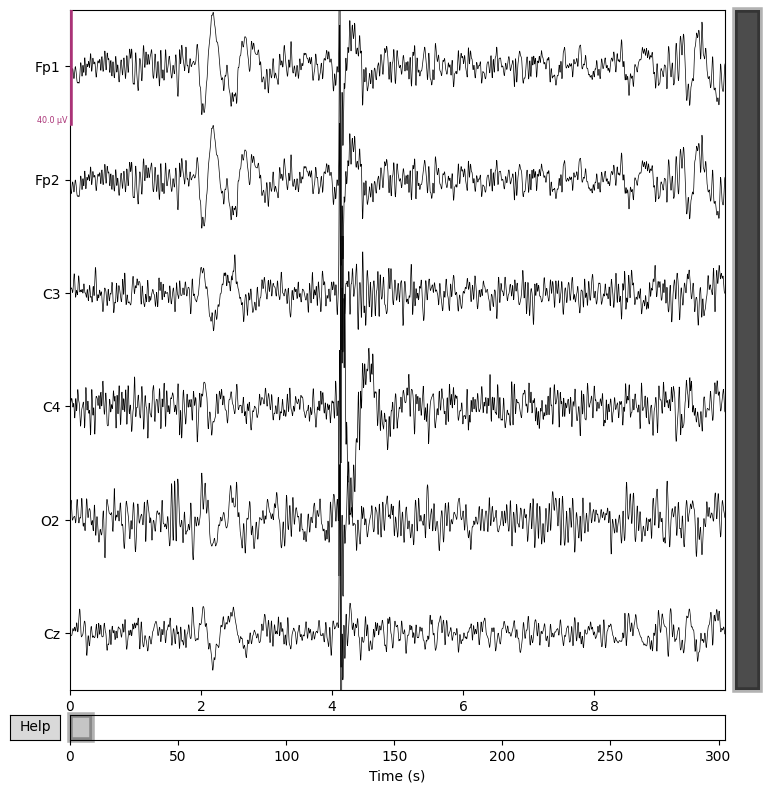

In [13]:
_ = preprocessed.plot()

In [14]:
SEGMENT_LENGTH = 10
SFREQ = 1000 / 4
CHUNK_SAMPLES = int(SEGMENT_LENGTH * SFREQ)

df = preprocessed.to_data_frame()
df

,time,Fp1,Fp2,C3,C4,O2,Cz
0,0.000000,0.021768,0.020920,0.024269,-0.022201,-0.047920,0.003164
1,0.003906,-1.361814,-1.368493,0.586706,0.494326,2.123809,-0.474533
2,0.007812,-2.780180,-2.792508,1.112385,0.864373,4.348426,-0.752496
3,0.011719,-4.062679,-4.079898,1.524322,1.238974,6.190800,-0.811519
4,0.015625,-4.878949,-4.899495,1.776015,1.785213,6.995631,-0.778415
...,...,...,...,...,...,...,...
77563,302.980469,-0.509295,-0.531010,4.629638,0.996757,-9.265093,4.679004
77564,302.984375,-1.668174,-1.691613,4.275679,1.625323,-7.323013,4.781798
77565,302.988281,-1.962546,-1.982718,3.311376,1.630763,-4.786802,3.789927
77566,302.992188,-1.312469,-1.324556,1.819727,1.021085,-2.239010,2.035223


In [15]:
df.describe()

,time,Fp1,Fp2,C3,C4,O2,Cz
count,77568.000000,77568.000000,77568.000000,77568.000000,77568.000000,77568.000000,77568.000000
mean,151.498047,0.000018,-0.000807,0.002012,-0.001297,0.000087,-0.000013
std,87.469130,22.935240,22.920530,22.885531,29.581057,23.593252,21.921867
min,0.000000,-1058.537500,-1057.654095,-1062.217041,-1196.654417,-909.533920,-894.431639
25%,75.749023,-2.537061,-2.549459,-2.288976,-2.482368,-3.575988,-2.113859
50%,151.498047,-0.026113,-0.027052,0.007021,0.016049,0.005312,-0.001047
75%,227.247070,2.563810,2.573305,2.326909,2.479012,3.631031,2.120178
max,302.996094,964.178162,963.406802,961.823549,1179.819321,1025.116478,1010.949360


In [16]:
chunks = [df.iloc[i : i + CHUNK_SAMPLES] for i in range(0, len(df), CHUNK_SAMPLES)]
print(len(chunks))
chunks[0].shape

32


(2500, 7)

In [17]:
# test = pd.DataFrame([[1,5,10], [4,5,6]])
# print(test)
# print(zscore(test, axis=0))

for chunk in chunks:
    # print(chunk)
    norm = pd.DataFrame(zscore(chunk, axis=0))  # hope this is correct axis
    print(norm)
    break

# TODO each segment before sending into classifier -> Z-score
# norm = zscore(raw) # TODO Make sure this is in the proper axis
# norm

          time       Fp1       Fp2        C3        C4        O2        Cz
0    -1.731358 -0.000383 -0.000405  0.005954  0.000704 -0.010071  0.004472
1    -1.729972 -0.239183 -0.239299  0.120135  0.031451  0.374103 -0.100554
2    -1.728587 -0.483986 -0.484144  0.226854  0.053478  0.767632 -0.161666
3    -1.727201 -0.705339 -0.705497  0.310482  0.075776  1.093544 -0.174643
4    -1.725816 -0.846223 -0.846417  0.361578  0.108291  1.235917 -0.167365
...        ...       ...       ...       ...       ...       ...       ...
2495  1.725816 -0.747929 -0.749466  0.822806 -0.065657  0.539180  0.592376
2496  1.727201 -0.686709 -0.687124  0.474442 -0.075033  0.719663  0.622263
2497  1.728587 -0.638782 -0.638579  0.275471 -0.079820  0.779200  0.658308
2498  1.729972 -0.658719 -0.658545  0.275481 -0.055344  0.701414  0.715498
2499  1.731358 -0.773137 -0.773414  0.405849  0.019406  0.527586  0.806895

[2500 rows x 7 columns]


In [18]:
channel = chunk["Fp1"]

In [19]:
print(channel)

0       0.021768
1      -1.361814
2      -2.780180
3      -4.062679
4      -4.878949
          ...   
2495   -4.309444
2496   -3.954737
2497   -3.677059
2498   -3.792571
2499   -4.455498
Name: Fp1, Length: 2500, dtype: float64


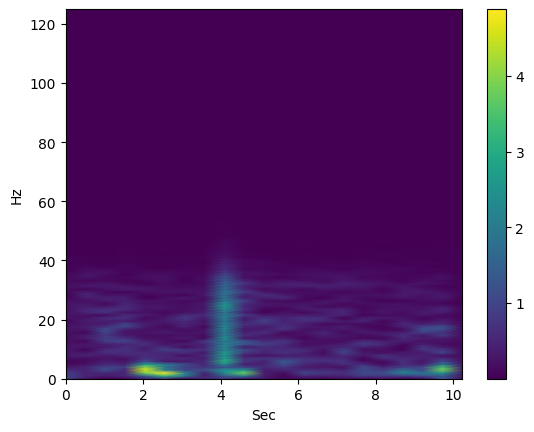

In [22]:
f, t, Zxx = stft(channel, fs=SFREQ, nperseg=256)

plt.pcolormesh(t, f, np.abs(Zxx), shading="gouraud")
plt.ylabel("Hz")
plt.xlabel("Sec")
plt.colorbar()
plt.show()

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import ShortTimeFFT
from scipy.signal.windows import hann  # or another window

# parameters
fs = SFREQ
nperseg = 256
noverlap = nperseg // 2  # e.g., 50% overlap
hop = nperseg - noverlap

# window
win = hann(nperseg, sym=True)

# create transformer
SFT = ShortTimeFFT(win, hop=hop, fs=fs, scale_to="magnitude")
# Note: scale_to can be 'magnitude', 'psd', or None. :contentReference[oaicite:4]{index=4}

# compute STFT
Sxx = SFT.stft(
    channel.to_numpy()
)  # shape: (freq_bins, time_slices) :contentReference[oaicite:5]{index=5}
print(Sxx.shape)


# get time and frequency axes
f = SFT.f  # frequency values in Hz :contentReference[oaicite:6]{index=6}
t = SFT.t(len(channel))  # times in seconds for each slice

# plot
plt.pcolormesh(t, f, np.abs(Sxx), shading="auto")
plt.ylabel("Hz")
plt.xlabel("Sec")
plt.title("ShortTimeFFT Spectrogram")
plt.show()

print(Sxx)

NameError: name 'channel' is not defined

# CANE dataset

In [3]:
df = pd.read_csv(CANE_DIR / "anxiety/ec/1027_EC.csv")
print(df.shape)
# df = df.iloc[::2].reset_index(drop=True)
# print(df.shape)

(208082, 13)


In [4]:
print(df["timestamp"].iloc[-1])
print(df["timestamp"].iloc[0])
sr = df.shape[0] / (df["timestamp"].iloc[-1] - df["timestamp"].iloc[0]) * 1000
print(sr)

1754135519227.0
1754135102298.0
499.0825776091373


In [5]:
eeg_channels = ["d1", "d2", "d3", "d4", "d5", "d6", "d7", "d8"]
df = df[eeg_channels]
df.describe()

,d1,d2,d3,d4,d5,d6,d7,d8
count,208082.000000,208082.000000,208082.000000,208082.000000,208082.000000,208082.000000,208082.000000,208082.000000
mean,52902.305316,60228.028808,46194.937737,44959.298548,22415.887494,51036.799823,48954.093105,64601.603341
std,2581.393616,2219.017626,2890.405927,2315.535234,3340.791638,2210.523718,2686.994731,3134.288619
min,31746.780000,39278.430000,25471.395000,26507.970000,2339.010000,32114.430000,31195.935000,47390.130000
25%,51455.981250,59351.096250,45670.455000,43344.146250,21212.651250,49357.935000,47276.775000,62277.896250
50%,52677.945000,60002.550000,46944.450000,44682.570000,22524.660000,51078.217500,48484.170000,63679.095000
75%,54545.838750,61618.308750,47782.530000,46090.980000,23997.780000,52614.135000,49952.227500,67334.310000
max,65289.105000,70465.095000,58340.610000,53124.480000,37287.675000,57151.710000,56704.095000,72974.520000


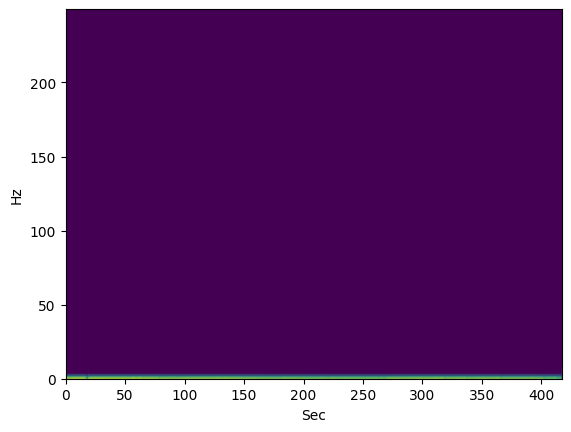

In [6]:
f, t, Zxx = stft(df["d4"], fs=sr, nperseg=256)

plt.pcolormesh(t, f, np.abs(Zxx), shading="gouraud")
plt.ylabel("Hz")
plt.xlabel("Sec")
plt.show()

In [32]:
df_scaled = df - df.mean()
df_scaled.describe()

,d1,d2,d3,d4,d5,d6,d7,d8
count,2.080820e+05,2.080820e+05,2.080820e+05,2.080820e+05,2.080820e+05,2.080820e+05,2.080820e+05,2.080820e+05
mean,-7.734092e-12,6.946361e-12,-4.296718e-13,-4.010270e-12,-2.578031e-12,-2.005135e-12,-4.296718e-13,-4.869614e-12
std,2.581394e+03,2.219018e+03,2.890406e+03,2.315535e+03,3.340792e+03,2.210524e+03,2.686995e+03,3.134289e+03
min,-2.115553e+04,-2.094960e+04,-2.072354e+04,-1.845133e+04,-2.007688e+04,-1.892237e+04,-1.775816e+04,-1.721147e+04
25%,-1.446324e+03,-8.769326e+02,-5.244827e+02,-1.615152e+03,-1.203236e+03,-1.678865e+03,-1.677318e+03,-2.323707e+03
50%,-2.243603e+02,-2.254788e+02,7.495123e+02,-2.767285e+02,1.087725e+02,4.141768e+01,-4.699231e+02,-9.225083e+02
75%,1.643533e+03,1.390280e+03,1.587592e+03,1.131681e+03,1.581893e+03,1.577335e+03,9.981344e+02,2.732707e+03
max,1.238680e+04,1.023707e+04,1.214567e+04,8.165181e+03,1.487179e+04,6.114910e+03,7.750002e+03,8.372917e+03


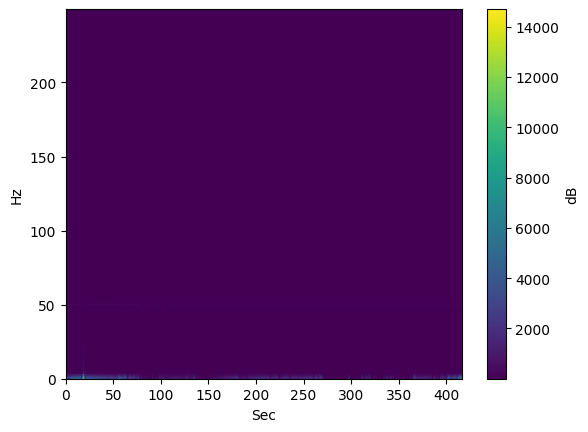

In [18]:
f, t, Zxx = stft(df_scaled["d4"], fs=sr, nperseg=256)

plt.pcolormesh(t, f, np.abs(Zxx), shading="gouraud")
plt.ylabel("Hz")
plt.xlabel("Sec")
plt.colorbar(label="dB")  # probably not for the np.abs onyl

plt.show()

499.0825776091373


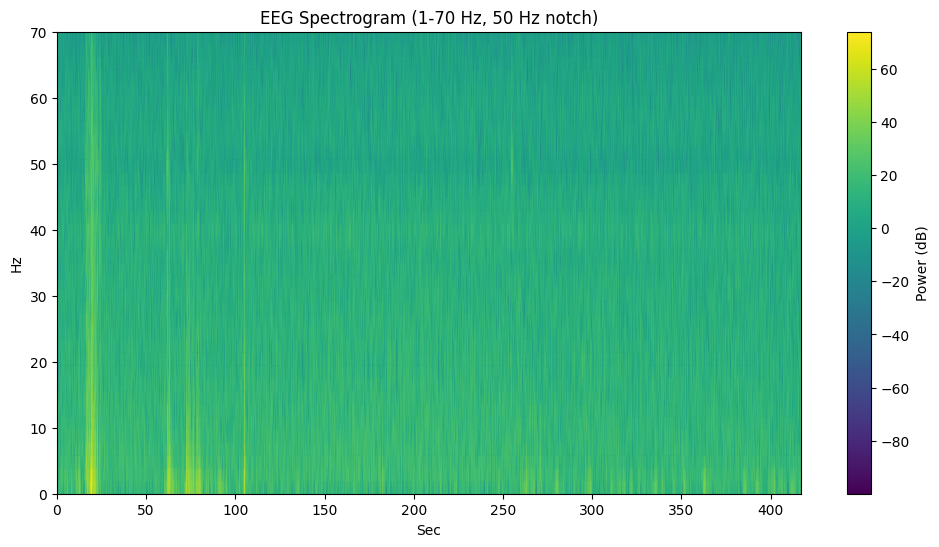

In [38]:
from scipy.signal import butter, filtfilt, iirnotch


def bandpass_filter(data, lowcut=1.0, highcut=70.0, fs=sr, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype="band")
    return filtfilt(b, a, data)


def notch_filter(data, notch_freq=50.0, fs=sr, quality=30):
    """
    Apply notch filter to remove powerline interference
    """
    # Use the actual sampling rate, not normalized
    b, a = iirnotch(notch_freq, quality, fs)
    return filtfilt(b, a, data)


# Apply bandpass filter
signal = bandpass_filter(df_scaled["d4"], lowcut=1.0, highcut=70.0, fs=sr)

# Apply notch filter to remove 50 Hz powerline noise
signal = notch_filter(signal, notch_freq=50.0, fs=sr)

# Compute STFT
f, t, Zxx = stft(signal, fs=sr, nperseg=256)

print(sr)
# Plot with log scale (recommended for better visualization)
plt.figure(figsize=(12, 6))
plt.pcolormesh(t, f, 10 * np.log10(np.abs(Zxx) ** 2 + 1e-10), shading="gouraud")
# plt.pcolormesh(t, f, np.abs(Zxx), shading="gouraud")
plt.ylabel("Hz")
plt.xlabel("Sec")
plt.ylim([0, 70])  # Show full filtered range
plt.colorbar(label="Power (dB)")
plt.title("EEG Spectrogram (1-70 Hz, 50 Hz notch)")
plt.show()

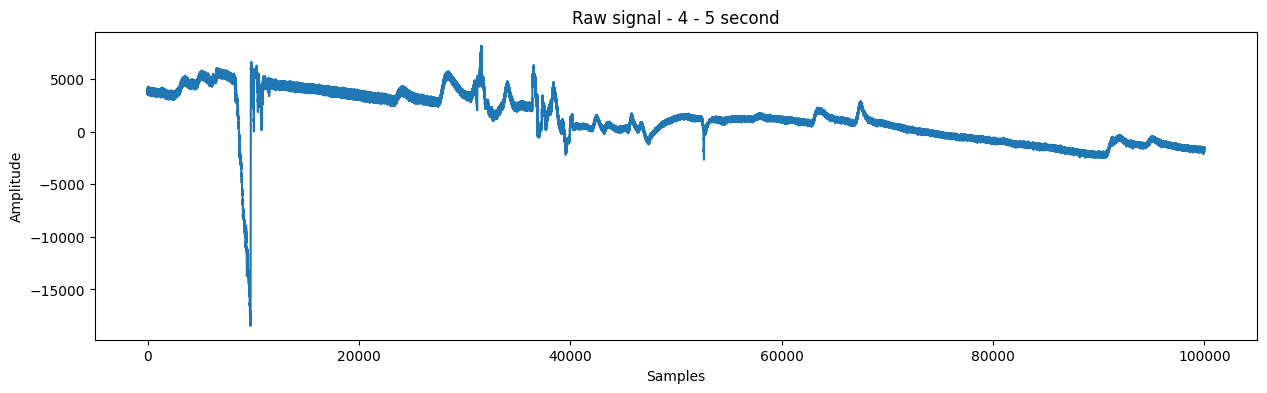

Any NaN values: False
Any inf values: False
Signal range: 26507.97 to 53124.48
Signal std: 2315.535233619226


In [55]:
# 1. Check the raw signal quality
plt.figure(figsize=(15, 4))
plt.plot(df_scaled["d4"][:100000])  # First 10 seconds at 500 Hz
plt.title("Raw signal - 4 - 5 second")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

# 2. Check if there are artifacts/bad values
print(f"Any NaN values: {df['d4'].isna().any()}")
print(f"Any inf values: {np.isinf(df['d4']).any()}")
print(f"Signal range: {df['d4'].min()} to {df['d4'].max()}")
print(f"Signal std: {df['d4'].std()}")

In [ ]:
from scipy.signal import detrend
from scipy.stats import zscore


def robust_preprocess_eeg(data, fs, artifact_threshold=5):
    """
    Robust EEG preprocessing with artifact removal

    Parameters:
    - data: raw EEG signal
    - fs: sampling rate
    - artifact_threshold: z-score threshold for artifact removal (default: 5)
    """
    signal = np.array(data, dtype=float)

    # 1. Remove linear trend (handles slow drifts)
    signal = detrend(signal, type="linear")

    # 2. Identify and interpolate artifacts (spikes)
    z_scores = np.abs(zscore(signal))
    artifact_indices = np.where(z_scores > artifact_threshold)[0]

    if len(artifact_indices) > 0:
        artifact_pct = len(artifact_indices) / len(signal) * 100
        print(f"Found {len(artifact_indices)} artifact samples ({artifact_pct:.2f}%)")

        # Simple interpolation: replace artifacts with neighboring values
        for idx in artifact_indices:
            # Use a window of ±50 samples around artifact
            window_start = max(0, idx - 50)
            window_end = min(len(signal), idx + 50)

            # Get non-artifact neighbors
            neighbors = signal[window_start:window_end]
            neighbor_zscores = np.abs(zscore(neighbors))
            valid_neighbors = neighbors[neighbor_zscores < 3]

            if len(valid_neighbors) > 0:
                signal[idx] = np.median(valid_neighbors)

    # 3. Bandpass filter (0.5-50 Hz for EEG)
    nyq = 0.5 * fs
    b, a = butter(4, [0.5 / nyq, 50.0 / nyq], btype="band")
    signal = filtfilt(b, a, signal)

    # 4. Notch filter at 50 Hz (powerline noise)
    b, a = iirnotch(50.0, Q=30, fs=fs)
    signal = filtfilt(b, a, signal)

    return signal


# Apply preprocessing
signal_clean = robust_preprocess_eeg(df_scaled["d4"], fs=sr, artifact_threshold=5)

# Plot the cleaned signal
plt.figure(figsize=(15, 4))
plt.plot(signal_clean[:5000])
plt.title("Cleaned signal - first 10 seconds")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

# Create spectrogram
f, t, Zxx = stft(signal_clean[:5000], fs=sr, nperseg=512, noverlap=256)

plt.figure(figsize=(14, 6))
plt.pcolormesh(
    t,
    f,
    10 * np.log10(np.abs(Zxx) ** 2 + 1e-10),
    shading="gouraud",
    cmap="viridis",
    vmin=-20,
    vmax=40,
)
plt.ylabel("Hz")
plt.xlabel("Sec")
plt.ylim([0, 120])
plt.colorbar(label="Power (dB)")
plt.title("EEG Spectrogram (Artifact Removed)")
plt.tight_layout()
plt.show()

Clipped 742 samples


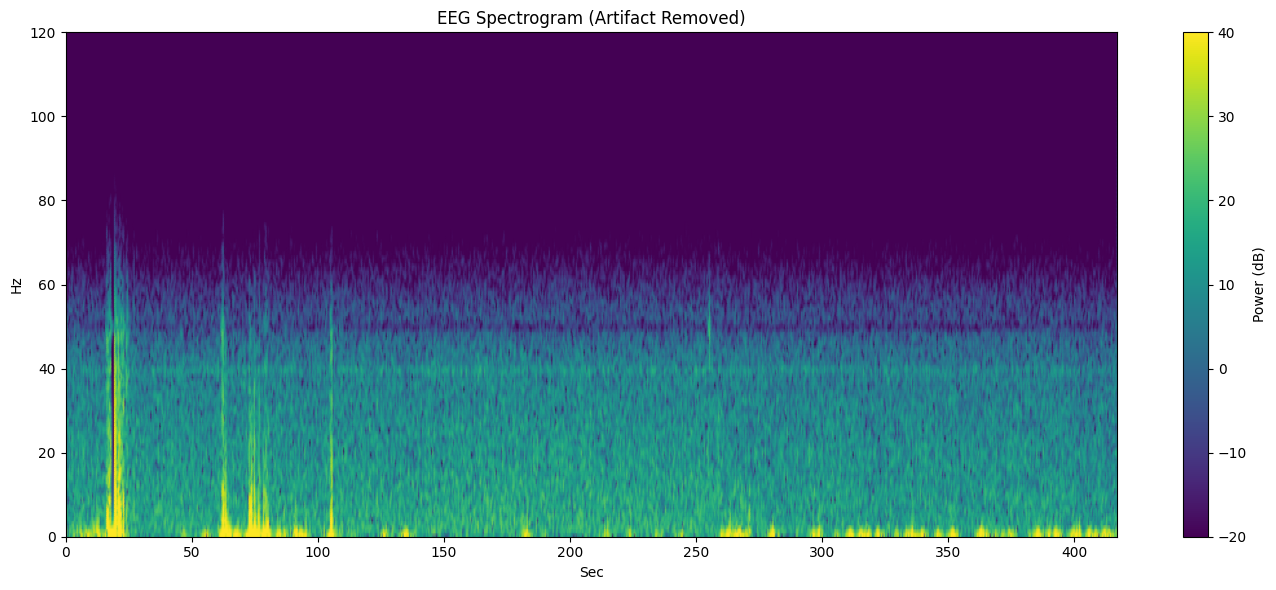

In [63]:
def aggressive_artifact_removal(data, fs, threshold_std=5):
    """Remove artifacts using median filtering"""
    signal = np.array(data, dtype=float)

    # Detrend first
    signal = detrend(signal, type="linear")

    # Calculate median absolute deviation
    median = np.median(signal)
    mad = np.median(np.abs(signal - median))
    threshold = threshold_std * 1.4826 * mad  # Convert MAD to std equivalent

    # Clip extreme values
    signal_clipped = np.clip(signal, median - threshold, median + threshold)

    print(f"Clipped {np.sum(signal != signal_clipped)} samples")

    return signal_clipped


# Try this approach
signal_clean = aggressive_artifact_removal(df_scaled["d4"], sr, threshold_std=5)

# Then apply filters
nyq = 0.5 * sr
b, a = butter(4, [0.5 / nyq, 50.0 / nyq], btype="band")
signal_clean = filtfilt(b, a, signal_clean)

b, a = iirnotch(50.0, Q=30, fs=sr)
signal_clean = filtfilt(b, a, signal_clean)
f, t, Zxx = stft(signal_clean, fs=sr, nperseg=512, noverlap=256)

plt.figure(figsize=(14, 6))
plt.pcolormesh(
    t,
    f,
    10 * np.log10(np.abs(Zxx) ** 2 + 1e-10),
    shading="gouraud",
    cmap="viridis",
    vmin=-20,
    vmax=40,
)
plt.ylabel("Hz")
plt.xlabel("Sec")
plt.ylim([0, 120])
plt.colorbar(label="Power (dB)")
plt.title("EEG Spectrogram (Artifact Removed)")
plt.tight_layout()
plt.show()

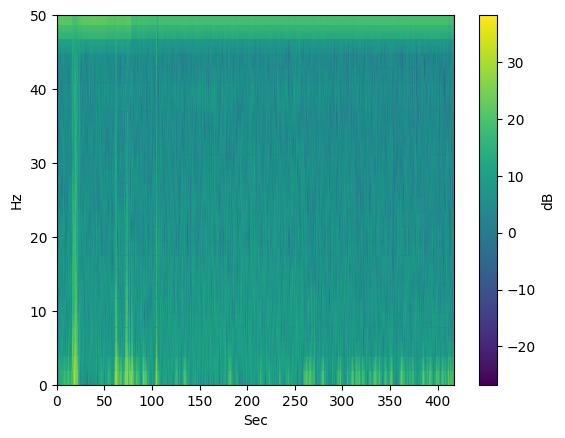

In [14]:
# Option 2: High-pass filter (better for removing slow drifts)
from scipy.signal import butter, filtfilt


def highpass_filter(data, cutoff=0.5, fs=sr, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype="high", analog=False)
    return filtfilt(b, a, data)


signal = highpass_filter(df_scaled["d4"], cutoff=0.5, fs=sr)

# Then compute STFT
f, t, Zxx = stft(signal, fs=sr, nperseg=256)

# Use log scale for better visualization
# plt.pcolormesh(t, f, 10 * np.log10(np.abs(Zxx) + 1e-10), shading="gouraud")
plt.pcolormesh(t, f, np.abs(Zxx), shading="gouraud")
plt.ylabel("Hz")
plt.xlabel("Sec")
plt.ylim([0, 50])  # Focus on EEG-relevant frequencies
plt.colorbar(label="dB")  # probably not for the np.abs onyl
plt.show()

In [19]:
df_scaled = df_scaled / (df.std())
df_scaled.describe()

,d1,d2,d3,d4,d5,d6,d7,d8
count,2.080820e+05,2.080820e+05,2.080820e+05,2.080820e+05,2.080820e+05,2.080820e+05,2.080820e+05,2.080820e+05
mean,-2.937210e-15,3.181977e-15,-1.398671e-16,-1.748339e-15,-8.042360e-16,-9.790699e-16,-1.748339e-16,-1.538538e-15
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-8.195389e+00,-9.440934e+00,-7.169769e+00,-7.968494e+00,-6.009617e+00,-8.560130e+00,-6.608929e+00,-5.491349e+00
25%,-5.602881e-01,-3.951895e-01,-1.814564e-01,-6.975287e-01,-3.601650e-01,-7.594874e-01,-6.242357e-01,-7.413826e-01
50%,-8.691442e-02,-1.016120e-01,2.593104e-01,-1.195095e-01,3.255890e-02,1.873659e-02,-1.748880e-01,-2.943278e-01
75%,6.366846e-01,6.265295e-01,5.492627e-01,4.887343e-01,4.735083e-01,7.135572e-01,3.714687e-01,8.718746e-01
max,4.798493e+00,4.613333e+00,4.202065e+00,3.526261e+00,4.451576e+00,2.766272e+00,2.884264e+00,2.671393e+00


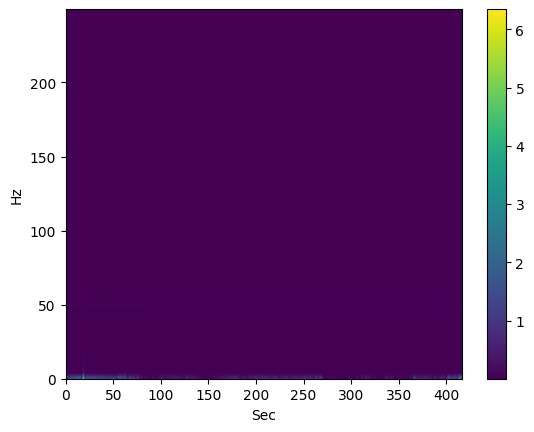

In [20]:
f, t, Zxx = stft(df_scaled["d4"], fs=sr, nperseg=256)

plt.pcolormesh(t, f, np.abs(Zxx), shading="gouraud")
plt.ylabel("Hz")
plt.xlabel("Sec")
plt.colorbar()
plt.show()

In [50]:
# Avoid log(0) by adding a small epsilon
# eps = 1e-9
# df_scaled = np.sign(df) * np.log10(np.abs(df) + eps)
# df_scaled = (df_scaled - df_scaled.mean()) / df_scaled.std()
# df_scaled = df_scaled / 10e4
# df_scaled.describe()

In [21]:
# Extract EEG channels
data = df_scaled.to_numpy()  # shape (n_channels, n_samples)
data.shape

(208082, 8)

In [22]:
transposed = data.T
transposed.shape

(8, 208082)

Creating RawArray with float64 data, n_channels=8, n_times=208082
    Range : 0 ... 208081 =      0.000 ...  6936.033 secs
Ready.
Filtering raw data in 1 contiguous segment
Removed notch frequencies (Hz):
     15.00 : 11088 windows


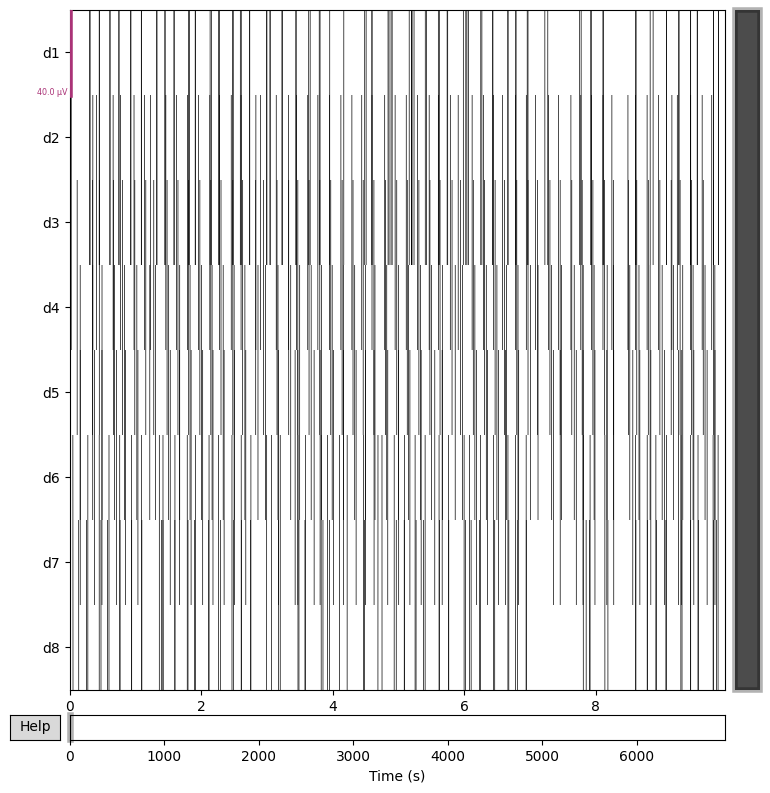

In [31]:
sfreq = 30  # replace with your actual sampling rate
# Create MNE info
info = mne.create_info(ch_names=eeg_channels, sfreq=sfreq, ch_types="eeg")

# Create Raw object
raw = mne.io.RawArray(transposed, info)

# raw = raw.filter(l_freq=1, h_freq=70, method="iir")
# raw = raw.notch_filter(freqs=50)
raw = raw.notch_filter(
    freqs=50, picks="eeg", method="spectrum_fit", filter_length="auto", phase="zero"
)
# print(raw.info)
_ = raw.plot()  # scalings="auto"

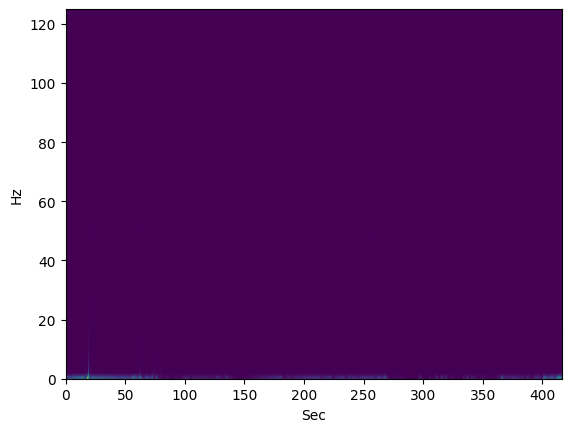

In [56]:
df = raw.to_data_frame()
f, t, Zxx = stft(df["d4"], fs=SFREQ, nperseg=256)

plt.pcolormesh(t, f, np.abs(Zxx), shading="gouraud")
plt.ylabel("Hz")
plt.xlabel("Sec")
plt.show()

In [44]:
norm = zscore(data)
norm

array([[-1.73203416,  1.11072081,  1.49429967, ...,  2.07077778,
         2.12145365,  2.03174285],
       [-1.73200086,  1.158802  ,  1.5555043 , ...,  2.03594693,
         2.16427069,  2.07178   ],
       [-1.73196757,  1.11248547,  1.49809612, ...,  2.01917219,
         2.13509014,  2.05685447],
       ...,
       [ 1.73196757, -2.23492229, -3.10803798, ..., -2.43249684,
        -2.86113877, -2.47316258],
       [ 1.73200086, -2.23371408, -3.10527781, ..., -2.42919756,
        -2.85679173, -2.46757958],
       [ 1.73203416, -2.2429432 , -3.11538769, ..., -2.41647917,
        -2.85972033, -2.4704049 ]], shape=(104041, 9))

In [45]:
print(norm.min(axis=0))
print(norm.max(axis=0))

[-1.73203416 -8.16637275 -9.40870589 -7.17010074 -7.9703437  -5.99635093
 -8.53156616 -6.59300687 -5.47561632]
[1.73203416 4.78277324 4.52237002 4.10063433 3.39319722 4.42479416
 2.77658511 2.89891376 2.6812141 ]


In [46]:
df = pd.DataFrame([[1, 2, 3, 4, 5], [1, 3, 5, 7, 9]])
df = df.T
print(df.shape)
print(df)
df = df.iloc[::2].reset_index(drop=True)
df

(5, 2)
   0  1
0  1  1
1  2  3
2  3  5
3  4  7
4  5  9


,0,1
0,1,1
1,3,5
2,5,9
